In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv('../Datasets/preprocessed_liver_data.csv')

X = df.drop('Result', axis=1)
y = df['Result']

# SMOTE APPLIED ONCE FOR VISUALIZATION

In [3]:
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)

# TRAIN RANDOM FOREST

In [4]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_bal, y_bal)

rf_probs = rf.predict_proba(X)[:,1]
rf_auc = roc_auc_score(y, rf_probs)

# TRAIN XGBOOST

In [5]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_bal, y_bal)

xgb_probs = xgb.predict_proba(X)[:,1]
xgb_auc = roc_auc_score(y, xgb_probs)

# TRAIN STACKED MODEL

In [6]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64,),
    max_iter=500,
    random_state=42
)

rf.fit(X_bal, y_bal)
xgb.fit(X_bal, y_bal)
mlp.fit(X_bal, y_bal)

stack_features = np.column_stack([
    rf.predict_proba(X)[:,1],
    xgb.predict_proba(X)[:,1],
    mlp.predict_proba(X)[:,1]
])

meta = LogisticRegression(
    solver='liblinear',
    random_state=42
)

meta.fit(stack_features, y)

stack_probs = meta.predict_proba(stack_features)[:,1]
stack_auc = roc_auc_score(y, stack_probs)

# COMPUTE ROC CURVES

In [7]:
rf_fpr, rf_tpr, _ = roc_curve(y, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y, xgb_probs)
stack_fpr, stack_tpr, _ = roc_curve(y, stack_probs)

# PLOT ROC CURVES FOR ALL MODELS

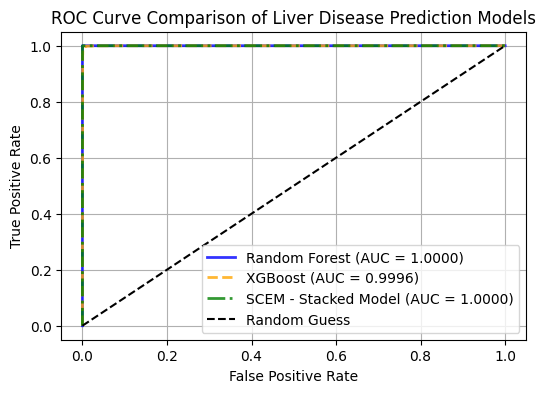

In [22]:
plt.figure(figsize=(6,4))

plt.plot(rf_fpr, rf_tpr,
         color='blue',
         linestyle='-',
         linewidth=2,
         alpha=0.8,
         label=f'Random Forest (AUC = {rf_auc:.4f})')

plt.plot(xgb_fpr, xgb_tpr,
         color='orange',
         linestyle='--',
         linewidth=2,
         alpha=0.8,
         label=f'XGBoost (AUC = {xgb_auc:.4f})')

plt.plot(stack_fpr, stack_tpr,
         color='green',
         linestyle='-.',
         linewidth=2,
         alpha=0.8,
         label=f'SCEM - Stacked Model (AUC = {stack_auc:.4f})')

plt.plot([0,1],[0,1],'k--',label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Liver Disease Prediction Models")

plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [12]:
plt.savefig("model_roc_comparison.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

# STACKED MODEL ARCHITECTURE DIAGRAM

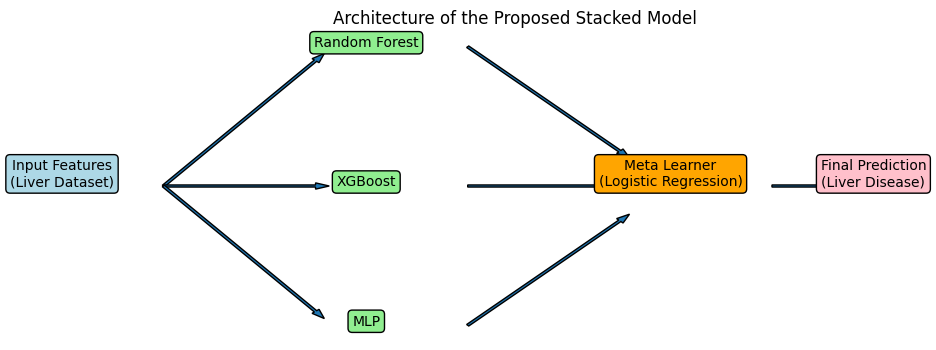

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.text(0.1,0.5,"Input Features\n(Liver Dataset)",bbox=dict(boxstyle="round",fc="lightblue"),ha='center')

plt.text(0.4,0.7,"Random Forest",bbox=dict(boxstyle="round",fc="lightgreen"),ha='center')
plt.text(0.4,0.5,"XGBoost",bbox=dict(boxstyle="round",fc="lightgreen"),ha='center')
plt.text(0.4,0.3,"MLP",bbox=dict(boxstyle="round",fc="lightgreen"),ha='center')

plt.text(0.7,0.5,"Meta Learner\n(Logistic Regression)",bbox=dict(boxstyle="round",fc="orange"),ha='center')

plt.text(0.9,0.5,"Final Prediction\n(Liver Disease)",bbox=dict(boxstyle="round",fc="pink"),ha='center')

plt.arrow(0.2,0.5,0.15,0.18,width=0.003)
plt.arrow(0.2,0.5,0.15,0,width=0.003)
plt.arrow(0.2,0.5,0.15,-0.18,width=0.003)

plt.arrow(0.5,0.7,0.15,-0.15,width=0.003)
plt.arrow(0.5,0.5,0.15,0,width=0.003)
plt.arrow(0.5,0.3,0.15,0.15,width=0.003)

plt.arrow(0.8,0.5,0.08,0,width=0.003)

plt.axis("off")
plt.title("Architecture of the Proposed Stacked Model")

plt.show()

In [14]:
plt.savefig("stacked_architecture.png",dpi=300,bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# MODEL PERFORMANCE COMPARISON (BAR CHART)

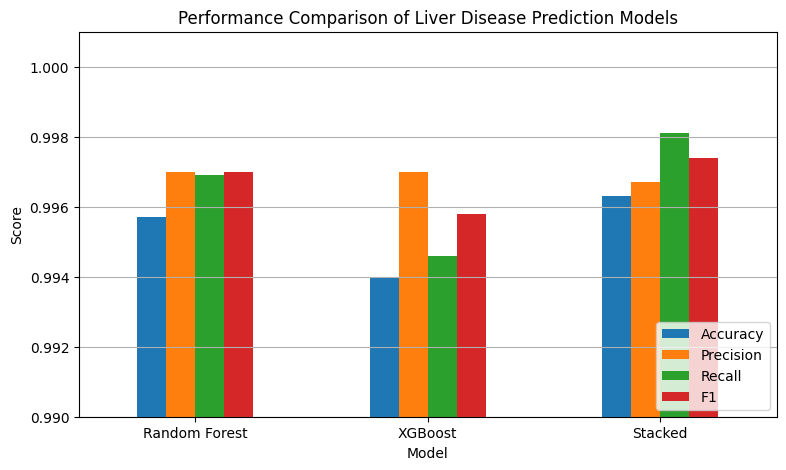

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Model":["Random Forest","XGBoost","Stacked"],
    "Accuracy":[0.9957,0.9940,0.9963],
    "Precision":[0.9970,0.9970,0.9967],
    "Recall":[0.9969,0.9946,0.9981],
    "F1":[0.9970,0.9958,0.9974]
}

df = pd.DataFrame(data)

df.set_index("Model").plot(kind="bar",figsize=(9,5))

plt.title("Performance Comparison of Liver Disease Prediction Models")
plt.ylabel("Score")
plt.ylim(0.99, 1.001)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y")

plt.show()

# RADAR CHART (MULTI METRIC COMPARISON)

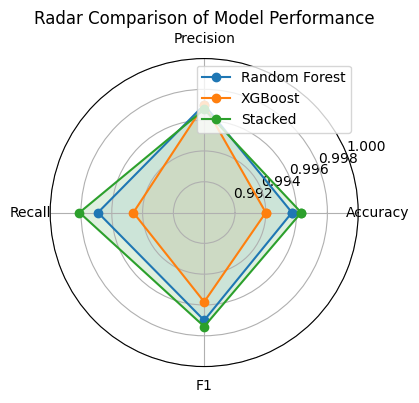

In [32]:
import numpy as np

labels = ["Accuracy","Precision","Recall","F1"]

rf = [0.9957,0.9970,0.9969,0.9970]
xgb = [0.9940,0.9970,0.9946,0.9958]
stack = [0.9963,0.9967,0.9981,0.9974]

angles = np.linspace(0,2*np.pi,len(labels),endpoint=False)
angles = np.concatenate((angles,[angles[0]]))

rf += [rf[0]]
xgb += [xgb[0]]
stack += [stack[0]]

fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111,polar=True)

ax.plot(angles,rf,marker='o',label="Random Forest")
ax.plot(angles,xgb,marker='o',label="XGBoost")
ax.plot(angles,stack,marker='o',label="Stacked")

ax.fill(angles, rf, alpha=0.1)
ax.fill(angles, xgb, alpha=0.1)
ax.fill(angles, stack, alpha=0.15)
ax.set_ylim(0.99,1.0)
ax.set_thetagrids(angles[:-1]*180/np.pi,labels)

plt.title("Radar Comparison of Model Performance")
plt.legend(loc="upper right")

plt.show()

# EXECUTION TIME COMPARISON

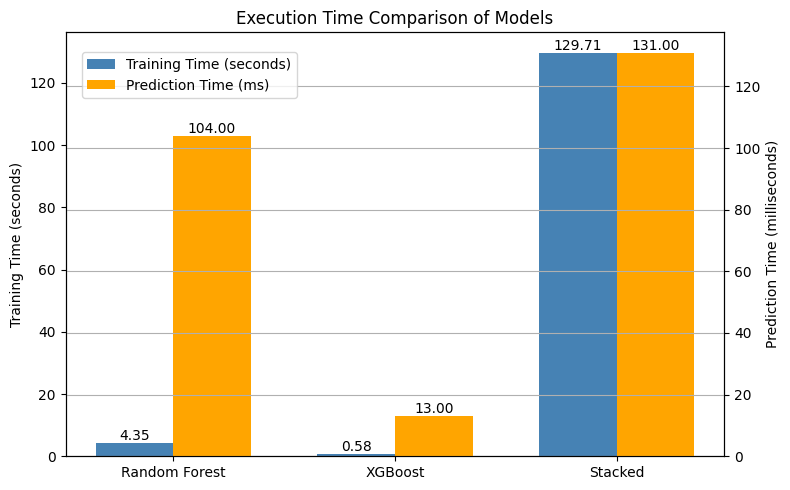

In [33]:
import numpy as np
import matplotlib.pyplot as plt

models = ["Random Forest", "XGBoost", "Stacked"]

train_time = [4.35, 0.58, 129.71]   # seconds
predict_time = [0.104, 0.013, 0.131]  # seconds

# Convert prediction time to milliseconds
predict_time_ms = np.array(predict_time) * 1000

x = np.arange(len(models))
width = 0.35

fig, ax1 = plt.subplots(figsize=(8,5))

# Training time bars
bars1 = ax1.bar(x - width/2, train_time, width,
                label="Training Time (seconds)",
                color="steelblue")

ax1.set_ylabel("Training Time (seconds)")
ax1.set_xticks(x)
ax1.set_xticklabels(models)

# Second axis for prediction time
ax2 = ax1.twinx()

bars2 = ax2.bar(x + width/2, predict_time_ms, width,
                label="Prediction Time (ms)",
                color="orange")

ax2.set_ylabel("Prediction Time (milliseconds)")

plt.title("Execution Time Comparison of Models")

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.2f}",
             ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.2f}",
             ha='center', va='bottom')

fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))

plt.grid(axis="y")
plt.tight_layout()

plt.show()